In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import plotly.express as px 

In [48]:
original_df= pd.read_csv(r'C:\Users\Mohamed Amr\Desktop\Sumerge AI internship\Song Recommender System\Dataset Excel\Songs_Recommender_System.csv')
df=original_df

In [49]:
original_df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,4BJqT0PrAfrxzMOxytFOIz,0.878000,10,0.665,-20.096,1,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",4,1921,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,7xPhfUan2yNtyFG0cUWkt8,0.000000,7,0.160,-12.441,1,Clancy Lowered the Boom,5,1921,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,1o6I8BglA6ylDMrIELygv1,0.913000,3,0.101,-14.850,1,Gati Bali,5,1921,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,3ftBPsC5vPBKxYSee08FDH,0.000028,5,0.381,-9.316,1,Danny Boy,3,1921,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,4d6HGyGT8e121BsdKmw9v6,0.000002,3,0.229,-10.096,1,When Irish Eyes Are Smiling,2,1921,0.0380,101.665


In [50]:
original_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   id                170653 non-null  object 
 9   instrumentalness  170653 non-null  float64
 10  key               170653 non-null  int64  
 11  liveness          170653 non-null  float64
 12  loudness          170653 non-null  float64
 13  mode              170653 non-null  int64  
 14  name              170653 non-null  object 
 15  popularity        170653 non-null  int64  
 16  release_date      17

In [51]:
# Count the total number of null values in each column
null_counts = original_df.isnull().sum()

# Print the count of null values
print("Count of null values in each column:")
print(null_counts)

# If you want the total number of null values across the entire DataFrame
total_nulls = original_df.isnull().sum().sum()
print(f"Total number of null values in the dataset: {total_nulls}")


Count of null values in each column:
valence             0
year                0
acousticness        0
artists             0
danceability        0
duration_ms         0
energy              0
explicit            0
id                  0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
name                0
popularity          0
release_date        0
speechiness         0
tempo               0
dtype: int64
Total number of null values in the dataset: 0


In [52]:
# sound_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'valence']
# fig = px.line(release_date, x='year', y=sound_features)
# fig.show()

In [53]:

df.drop(['id', 'release_date','name'], axis=1, inplace=True)
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,0.0380,101.665


In [54]:
df.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,5.199844,0.205839,-11.467990,0.706902,31.431794,0.098393,116.861590
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,3.515094,0.174805,5.697943,0.455184,21.826615,0.162740,30.708533
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,2.000000,0.098800,-14.615000,0.000000,11.000000,0.034900,93.421000
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,5.000000,0.136000,-10.580000,1.000000,33.000000,0.045000,114.729000
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,8.000000,0.261000,-7.183000,1.000000,48.000000,0.075600,135.537000
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,11.000000,1.000000,3.855000,1.000000,100.000000,0.970000,243.507000


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170653 entries, 0 to 170652
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   valence           170653 non-null  float64
 1   year              170653 non-null  int64  
 2   acousticness      170653 non-null  float64
 3   artists           170653 non-null  object 
 4   danceability      170653 non-null  float64
 5   duration_ms       170653 non-null  int64  
 6   energy            170653 non-null  float64
 7   explicit          170653 non-null  int64  
 8   instrumentalness  170653 non-null  float64
 9   key               170653 non-null  int64  
 10  liveness          170653 non-null  float64
 11  loudness          170653 non-null  float64
 12  mode              170653 non-null  int64  
 13  popularity        170653 non-null  int64  
 14  speechiness       170653 non-null  float64
 15  tempo             170653 non-null  float64
dtypes: float64(9), int64

In [56]:
df.head()

,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
0,0.0594,1921,0.982,"['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,0.0366,80.954
1,0.9630,1921,0.732,['Dennis Day'],0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,0.4150,60.936
2,0.0394,1921,0.961,['KHP Kridhamardawa Karaton Ngayogyakarta Hadi...,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,0.0339,110.339
3,0.1650,1921,0.967,['Frank Parker'],0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,0.0354,100.109
4,0.2530,1921,0.957,['Phil Regan'],0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,0.0380,101.665


## Encoding

In [57]:
#Frequency encoding 

artist_freq = df['artists'].value_counts() / len(df)
df['artists_encoded'] = df['artists'].map(artist_freq)



In [58]:
df = df.drop('artists',axis=1)

In [59]:
df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,0.0366,80.954,0.000012
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,0.4150,60.936,0.000029
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,0.0339,110.339,0.000123
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,0.0354,100.109,0.000006
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,0.0380,101.665,0.000018


## Standriazation

In [60]:
from sklearn.preprocessing import StandardScaler

In [61]:

# Select the features to standardize
features_to_standardize = [ 'key', 'popularity', 'tempo','loudness']

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform only the selected features
df[features_to_standardize] = scaler.fit_transform(df[features_to_standardize])

df.head()


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,1.365588,0.665,-1.514237,1,-1.256808,0.0366,-1.169307,0.000012
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,0.512123,0.160,-0.170766,1,-1.210993,0.4150,-1.821180,0.000029
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,-0.625830,0.101,-0.593551,1,-1.210993,0.0339,-0.212404,0.000123
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,-0.056853,0.381,0.377680,1,-1.302624,0.0354,-0.545537,0.000006
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,-0.625830,0.229,0.240788,1,-1.348440,0.0380,-0.494867,0.000018


In [62]:
df.describe()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
count,170653.000000,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,170653.000000,170653.000000,1.706530e+05,170653.000000,1.706530e+05,170653.000000,1.706530e+05,170653.000000,1.706530e+05,170653.000000
mean,0.528587,1976.787241,0.502115,0.537396,2.309483e+05,0.482389,0.084575,0.167010,9.626404e-17,0.205839,1.305727e-16,0.706902,-4.530073e-17,0.098393,-8.060865e-17,0.000491
std,0.263171,25.917853,0.376032,0.176138,1.261184e+05,0.267646,0.278249,0.313475,1.000003e+00,0.174805,1.000003e+00,0.455184,1.000003e+00,0.162740,1.000003e+00,0.001027
min,0.000000,1921.000000,0.000000,0.000000,5.108000e+03,0.000000,0.000000,0.000000,-1.479295e+00,0.000000,-8.517487e+00,0.000000,-1.440072e+00,0.000000,-3.805520e+00,0.000006
25%,0.317000,1956.000000,0.102000,0.415000,1.698270e+05,0.255000,0.000000,0.000000,-9.103181e-01,0.098800,-5.523080e-01,0.000000,-9.360982e-01,0.034900,-7.633272e-01,0.000029
50%,0.540000,1977.000000,0.516000,0.548000,2.074670e+05,0.471000,0.000000,0.000216,-5.685331e-02,0.136000,1.558444e-01,1.000000,7.184853e-02,0.045000,-6.944636e-02,0.000141
75%,0.747000,1999.000000,0.893000,0.668000,2.624000e+05,0.703000,0.000000,0.102000,7.966115e-01,0.261000,7.520262e-01,1.000000,7.590849e-01,0.075600,6.081523e-01,0.000457
max,1.000000,2020.000000,0.996000,0.988000,5.403500e+06,1.000000,1.000000,1.000000,1.650076e+00,1.000000,2.689222e+00,1.000000,3.141504e+00,0.970000,4.124123e+00,0.007096


## Visualizig data



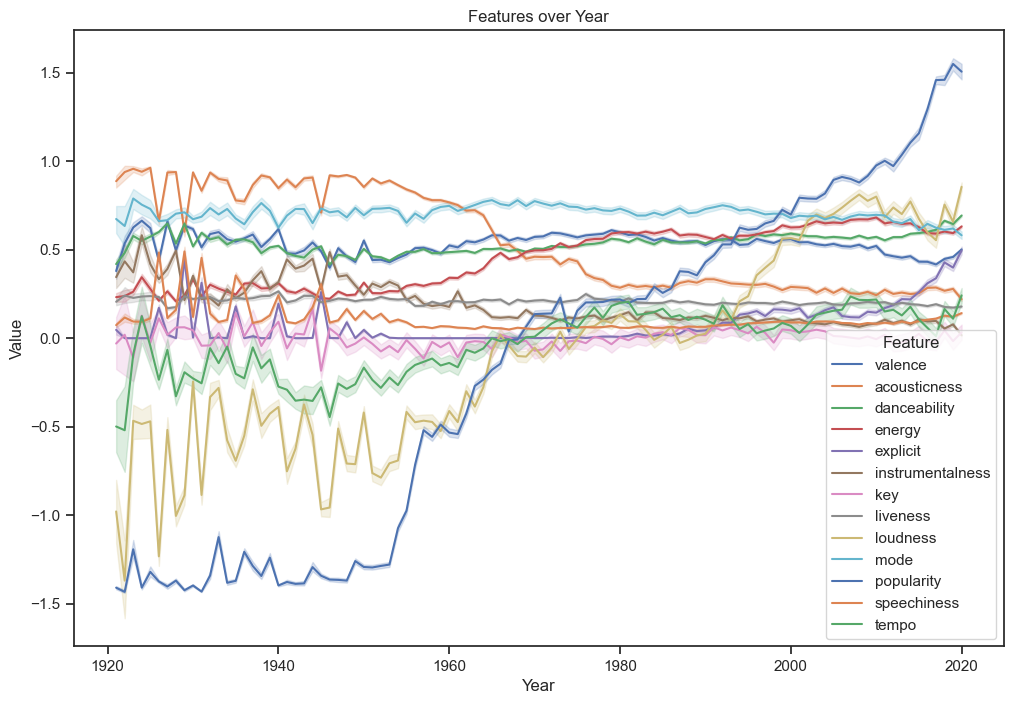

In [63]:

sns.set_theme(style="ticks")

features=df.drop(columns=['year','duration_ms','artists_encoded'],axis=1)  

plt.figure(figsize=(12, 8))
for feature in features:
    sns.lineplot(data=df, x='year', y=feature, label=feature)

plt.title('Features over Year')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend(title='Feature')
plt.show()


In [64]:
# Stand. the year

features_to_standardize = ['year']
scaler = StandardScaler()
df[features_to_standardize] = scaler.fit_transform(df[features_to_standardize])

df.head()


,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo,artists_encoded
0,0.0594,-2.15247,0.982,0.279,831667,0.211,0,0.878000,1.365588,0.665,-1.514237,1,-1.256808,0.0366,-1.169307,0.000012
1,0.9630,-2.15247,0.732,0.819,180533,0.341,0,0.000000,0.512123,0.160,-0.170766,1,-1.210993,0.4150,-1.821180,0.000029
2,0.0394,-2.15247,0.961,0.328,500062,0.166,0,0.913000,-0.625830,0.101,-0.593551,1,-1.210993,0.0339,-0.212404,0.000123
3,0.1650,-2.15247,0.967,0.275,210000,0.309,0,0.000028,-0.056853,0.381,0.377680,1,-1.302624,0.0354,-0.545537,0.000006
4,0.2530,-2.15247,0.957,0.418,166693,0.193,0,0.000002,-0.625830,0.229,0.240788,1,-1.348440,0.0380,-0.494867,0.000018


## Feature Selection 

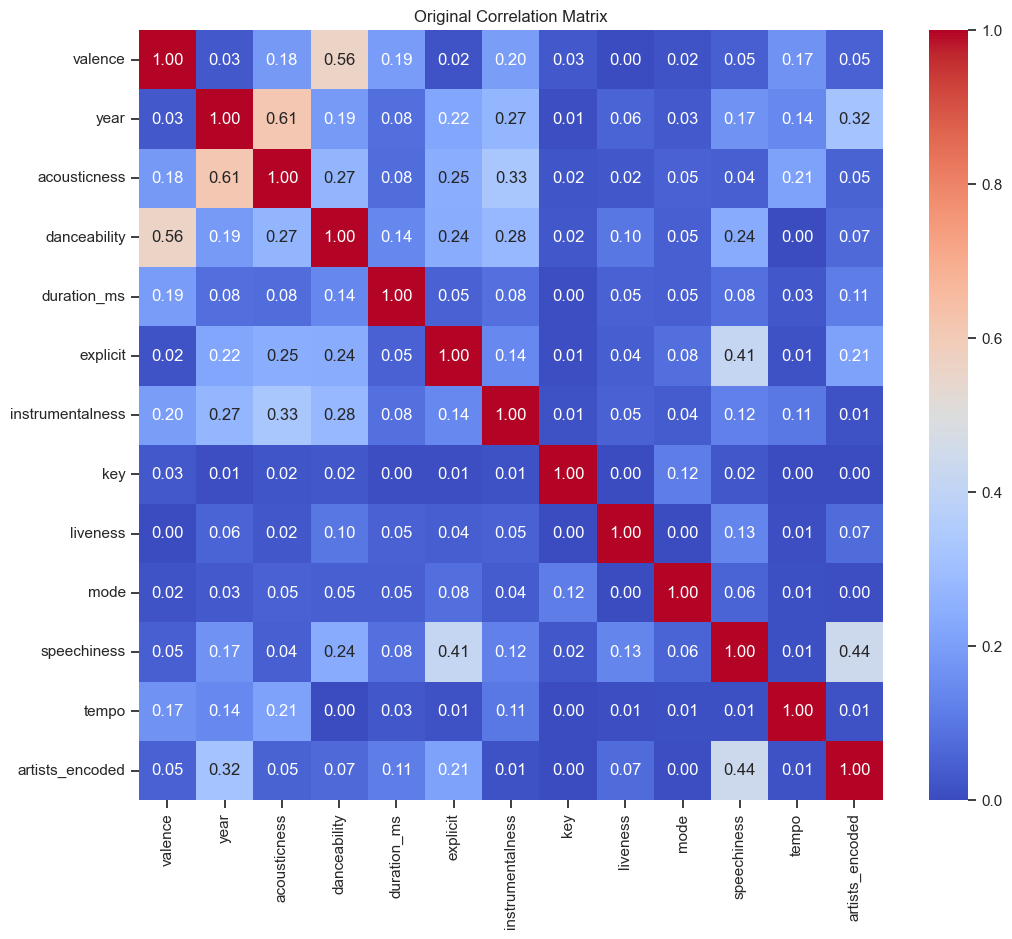

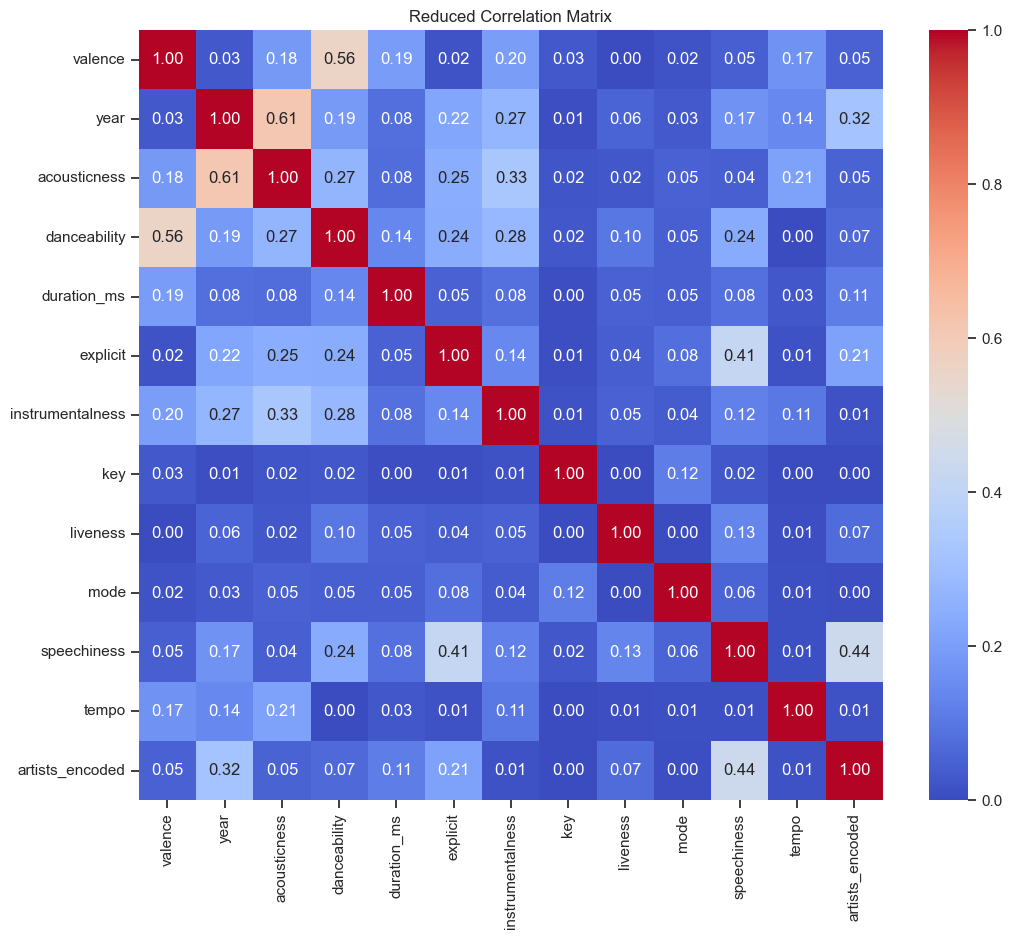

[]

In [66]:

correlation_matrix = df.corr().abs()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title('Original Correlation Matrix')
plt.show()

upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]

df = df.drop(columns=to_drop)

reduced_correlation_matrix = df.corr().abs()
plt.figure(figsize=(12, 10))
sns.heatmap(reduced_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title('Reduced Correlation Matrix')
plt.show()

to_drop



In [69]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]))

# Apply Variance Threshold
var_thresh = VarianceThreshold(threshold=0.1)
X_var_thresh = var_thresh.fit_transform(X_scaled)

# Get the selected feature indices
selected_indices_var_thresh = var_thresh.get_support(indices=True)
selected_features_var_thresh = df.columns[selected_indices_var_thresh]
print(f"Selected features: {list(selected_features_var_thresh)}")

Selected features: ['valence', 'year', 'acousticness', 'danceability', 'duration_ms', 'explicit', 'instrumentalness', 'key', 'liveness', 'mode', 'speechiness', 'tempo', 'artists_encoded']
